## N=2

In [21]:

import numpy as np
import torch
import torchvision
import matplotlib.pyplot as plt

import utils
import exp_models

In [22]:
# Reproducibility
SEED = 2019

np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

In [23]:
transform = torchvision.transforms.transforms.Compose([
    torchvision.transforms.transforms.ToTensor()
])
trainset = torchvision.datasets.FashionMNIST(root='/data/landelle/datasets', train=True, download=True, transform=transform)
testset = torchvision.datasets.FashionMNIST(root='/data/landelle/datasets', train=False, download=True, transform=transform)
#trainset, testset


In [24]:
BATCH_SIZE = 100
N_BATCHES_IN_TRAIN_SET = len(trainset) // BATCH_SIZE
N_BATCHES_IN_TEST_SET = len(testset) // BATCH_SIZE
NUM_WORKERS = 8

trainloader = torch.utils.data.DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
testloader = torch.utils.data.DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)


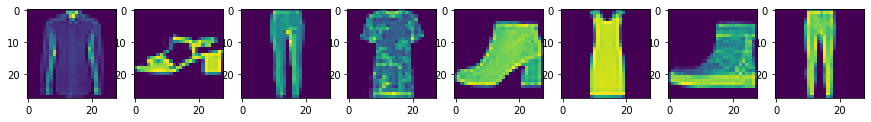

In [25]:
fig, axes = plt.subplots(1, 8, figsize=(15, 2))
for i in range(8):
    utils.show_np_arr(next(iter(trainloader))[0][i][0, :, :], ax=axes[i])
    pass

In [26]:

USE_CUDA = True
N_EPOCHS = 1
N_BATCHES = 1
LR = 0.001

model_getter = exp_models.CNN

def perform_experiment_OLD(lambdas):
    print("saving results in", RESULTS_FNAME)
    print_ = utils.get_print(True, fname=RESULTS_FNAME)
    test_accs = {}
    train_losses = {str(k):[] for k in lambdas}
    val_losses = {str(k):[] for k in lambdas}
    for lambda_ in lambdas:
        print_("Trying lambda=", lambda_)        

        device = torch.device('cuda' if USE_CUDA else 'cpu')
        model = model_getter().to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=LR)
        criterion = torch.nn.CrossEntropyLoss()

        lam_rs = lambda_.reshape((-1, 1, 1, 1, 1))
        lam_rs_tensor = torch.from_numpy(lam_rs).float().to(device)

        NMIX = lam_rs_tensor.shape[0]
        print_("Performing n-mixup with N-mix:", NMIX)
        first_batch = None

        # Train mode
        model.train()
        for epoch in range(1, N_EPOCHS + 1):
            for phase in ["train", "val"]:
                print_("Epoch[{}/{}]".format(epoch, N_EPOCHS))
                for batch_id, (images, labels) in enumerate(trainloader):
                    if N_BATCHES and batch_id > N_BATCHES:
                        break
                    labels, images = labels.to(device), images.to(device)
                    images_mx, ys, perms = utils.mixup_data_nmix(NMIX, images, labels, lam_rs_tensor)
                    outputs = model(images_mx)
                    loss = utils.mixup_criterion_nmix(criterion, outputs, ys, lam_rs_tensor)
                    loss_value = loss.item()

                    if first_batch is None:
                        print_('val loss:{:.4f} Epoch[{}/{}] Batch[{}/{}]'.format(
                                loss_value, epoch, N_EPOCHS, batch_id, N_BATCHES_IN_TRAIN_SET))
                        first_batch = images                    
                        print_("Batch shape:", first_batch.shape)
                        val_losses[str(lambda_)].append(loss_value)

                    optimizer.zero_grad()
                    if phase == "train":
                        loss.backward()
                        optimizer.step()
                        train_losses[str(lambda_)].append(loss_value)
                        if batch_id % 50 == 0:
                            print_(phase + ' loss:{:.4f} Epoch[{}/{}] Batch[{}/{}]'.format(
                                loss_value, epoch, N_EPOCHS, batch_id, N_BATCHES_IN_TRAIN_SET))
                    elif phase == "val":
                        print_(phase + ' loss:{:.4f} Epoch[{}/{}] Batch[{}/{}]'.format(
                                loss_value, epoch, N_EPOCHS, batch_id, N_BATCHES_IN_TRAIN_SET))
                        val_losses[str(lambda_)].append(loss_value)
                        break

        # Test mode
        model.eval()
        with torch.no_grad():
            correct = 0
            total = 0
            for images, labels in testloader:
                images = images.to(device)
                labels = labels.to(device)
                outputs = model(images)
                predicted = torch.argmax(outputs, dim=1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
            # Output test accuracy
            test_acc = 100 * correct / total
            print_('Test Accuracy of the model on the test images: {} %'.format(test_acc))
            test_accs[str(lambda_)] = test_acc


        del device, model, optimizer, criterion
    return test_accs, train_losses, val_losses, images_mx, ys

def perform_experiment(lambdas):
    print("saving results in", RESULTS_FNAME)
    print_ = utils.get_print(True, fname=RESULTS_FNAME)
    test_accs = {}
    train_losses = {str(k):[] for k in lambdas}
    val_losses = {str(k):[] for k in lambdas}
    for lambda_ in lambdas:
        print_("Trying lambda=", lambda_)        

        device = torch.device('cuda' if USE_CUDA else 'cpu')
        model = model_getter().to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=LR)
        criterion = torch.nn.CrossEntropyLoss()
        
        lam_rs = lambda_.reshape((-1, 1, 1, 1, 1))
        lam_rs_tensor = torch.from_numpy(lam_rs).float().to(device)

        NMIX = lam_rs_tensor.shape[0]
        print_("Performing n-mixup with N-mix:", NMIX)

        # Train mode
        model.train()
        for epoch in range(1, N_EPOCHS + 1):
            # Training on all batches
            print_("Epoch[{}/{}]".format(epoch, N_EPOCHS))
            for batch_id, (images, labels) in enumerate(trainloader):
                if N_BATCHES and batch_id > N_BATCHES:
                    break
                labels, images = labels.to(device), images.to(device)
                images_mx, ys, perms = utils.mixup_data_nmix(NMIX, images, labels, lam_rs_tensor, device)
                outputs = model(images_mx)
                loss = utils.mixup_criterion_nmix(criterion, outputs, ys, lam_rs_tensor)
                loss_value = loss.item()

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                train_losses[str(lambda_)].append(loss_value)
                if batch_id % 50 == 0:
                    print_('train loss:{:.4f} Epoch[{}/{}] Batch[{}/{}]'.format(
                        loss_value, epoch, N_EPOCHS, batch_id, N_BATCHES_IN_TRAIN_SET))
                    
            # Validating on one batch
            for images, labels in testloader:
                correct = 0
                total = 0
                images = images.to(device)
                labels = labels.to(device)
                outputs = model(images)
                predicted = torch.argmax(outputs, dim=1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
                val_acc = 100 * correct / total
                loss = utils.mixup_criterion_nmix(criterion, outputs, ys, lam_rs_tensor)
                loss_value = loss.item()

                print_('val loss:{:.4f} Epoch[{}/{}]'.format(
                        loss_value, epoch, N_EPOCHS))
                print_('val acc:{:.4f} Epoch[{}/{}]'.format(
                        val_acc, epoch, N_EPOCHS))
                val_losses[str(lambda_)].append(loss_value)
                break

        # Test mode
        model.eval()
        with torch.no_grad():
            correct = 0
            total = 0
            for images, labels in testloader:
                images = images.to(device)
                labels = labels.to(device)
                outputs = model(images)
                predicted = torch.argmax(outputs, dim=1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
            # Output test accuracy
            test_acc = 100 * correct / total
            print_('Test Accuracy of the model on the test images: {} %'.format(test_acc))
            test_accs[str(lambda_)] = test_acc


        del device, model, optimizer, criterion
    return test_accs, train_losses, val_losses, images_mx, ys


In [29]:

LAMBDAS = [np.array([1-l/8, l/8]) for l in range(5)]
LAMBDAS[2:3]

[array([0.75, 0.25])]

In [31]:

for i in range(1):
    RESULTS_FNAME = "r_fmn_cnn_n2_lin_det_DELETE"+str(i)
    with open("results/"+RESULTS_FNAME, "w"):pass
    print(RESULTS_FNAME, LAMBDAS)
    test_accs, train_losses, val_losses, images_mx, ys = perform_experiment(LAMBDAS[2:3])


r_fmn_cnn_n2_lin_det_DELETE0 [array([1., 0.]), array([0.875, 0.125]), array([0.75, 0.25]), array([0.625, 0.375]), array([0.5, 0.5])]
saving results in r_fmn_cnn_n2_lin_det_DELETE0
Trying lambda= [0.75 0.25]
Performing n-mixup with N-mix: 2
Epoch[1/1]
train loss:2.3684 Epoch[1/1] Batch[0/600]
val loss:2.5186 Epoch[1/1]
val acc:28.0000 Epoch[1/1]
Test Accuracy of the model on the test images: 34.64 %


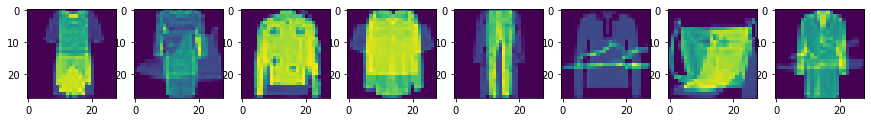

In [32]:
fig, axes = plt.subplots(1, 8, figsize=(15, 2))
for i in range(8):
    utils.show_np_arr(images_mx[i].cpu()[0, :, :], ax=axes[i])
    #axes[i].set_title(trainset.classes[ys[0][i]]+" + "+trainset.classes[ys[1][i]], fontsize=10)
    pass

In [26]:
test_accs

{'[1. 0.]': 85.55, '[0.75 0.25]': 85.15, '[0.5 0.5]': 84.04}

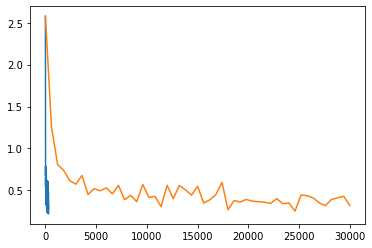

In [20]:
plt.plot(train_losses['[1. 0.]'])
plt.plot([i*600 for i in range(0, len(val_losses['[1. 0.]']))], val_losses['[1. 0.]'])

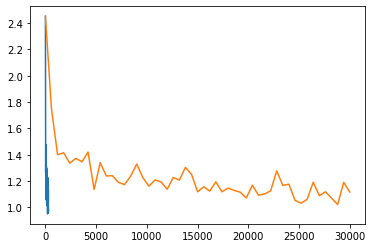

In [21]:
plt.plot(train_losses['[0.75 0.25]'])
plt.plot([i*600 for i in range(0, len(val_losses['[0.75 0.25]']))], val_losses['[0.75 0.25]'])

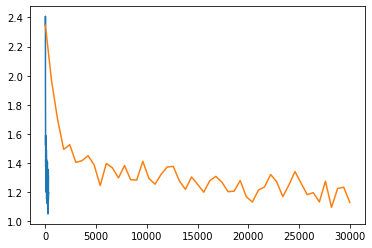

In [22]:
plt.plot(train_losses['[0.5 0.5]'])
plt.plot([i*600 for i in range(0, len(val_losses['[0.5 0.5]']))], val_losses['[0.5 0.5]'])

## N = 3

In [179]:
N_MIX = 3

In [194]:
def show_lambdas(lambdas):
    N = len(lambdas[0])
    for l in lambdas:
        xs = np.arange(N) / (N-1)
        plt.scatter(xs, l)
        plt.plot(xs, l)
    plt.show()

    
LAMBDAS2 = [np.array([1, 1/x, 1/(x*x), 1/(x*x*x), 1/(x*x*x*x)])[:N_MIX] for x in np.linspace(1., N_MIX, 4)]
LAMBDAS2.append(np.array([1, *[0 for _ in LAMBDAS2[0][1:]]]))
LAMBDAS2 = [l / l.sum() for l in LAMBDAS2]
LAMBDAS2.reverse()
print(LAMBDAS2)


[array([1., 0., 0., 0.]), array([0.75294118, 0.18823529, 0.04705882, 0.01176471]), array([0.675, 0.225, 0.075, 0.025]), array([0.53333333, 0.26666667, 0.13333333, 0.06666667]), array([0.25, 0.25, 0.25, 0.25])]


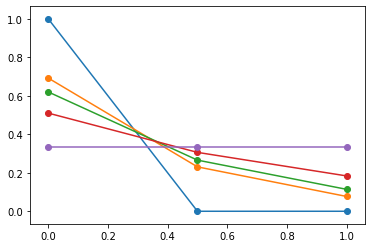

In [181]:
show_lambdas(LAMBDAS2)

In [182]:

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

LAMBDAS3 = [
    lam*np.array([1./N_MIX for _ in range(N_MIX)])+\
    (1-lam)*np.array([sigmoid(y) for y in np.linspace(-5, 5, N_MIX)])
    for lam in np.linspace(0., 1., N_MIX)]
LAMBDAS3 = [np.flip(l / l.sum()) for l in LAMBDAS3]
LAMBDAS3

[array([0.66220477, 0.33333333, 0.0044619 ]),
 array([0.53065619, 0.33333333, 0.13601047]),
 array([0.33333333, 0.33333333, 0.33333333])]

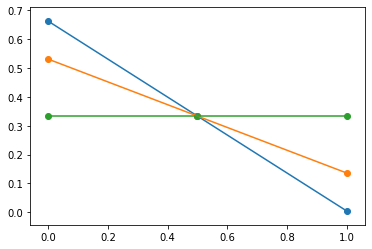

In [183]:
show_lambdas(LAMBDAS3)

In [195]:


USE_CUDA = True
RESULTS_FNAME = "r_fmn_cnn_n3"
N_EPOCHS = 100
N_BATCHES = None
LR = 0.001

print_ = utils.get_print(True, fname=RESULTS_FNAME)
model_getter = exp_models.CNN

test_accs, train_losses, val_losses, last_batch, last_ys = perform_experiment(LAMBDAS2)


Trying lambda= [1. 0. 0. 0.]
Performing n-mixup with N-mix: 4
Epoch[1/100]
val loss:2.3807 Epoch[1/100] Batch[0/600]
Batch shape: torch.Size([100, 1, 28, 28])
train loss:2.3807 Epoch[1/100] Batch[0/600]
train loss:0.7438 Epoch[1/100] Batch[50/600]
train loss:0.3994 Epoch[1/100] Batch[100/600]
train loss:0.4766 Epoch[1/100] Batch[150/600]
train loss:0.3583 Epoch[1/100] Batch[200/600]
train loss:0.3760 Epoch[1/100] Batch[250/600]
train loss:0.2550 Epoch[1/100] Batch[300/600]
train loss:0.3651 Epoch[1/100] Batch[350/600]
train loss:0.2889 Epoch[1/100] Batch[400/600]
train loss:0.2703 Epoch[1/100] Batch[450/600]
train loss:0.2718 Epoch[1/100] Batch[500/600]
train loss:0.4126 Epoch[1/100] Batch[550/600]
Epoch[1/100]
val loss:0.2876 Epoch[1/100] Batch[0/600]
Epoch[2/100]
train loss:0.2724 Epoch[2/100] Batch[0/600]
train loss:0.2910 Epoch[2/100] Batch[50/600]
train loss:0.2135 Epoch[2/100] Batch[100/600]
train loss:0.3113 Epoch[2/100] Batch[150/600]
train loss:0.2780 Epoch[2/100] Batch[200/60

train loss:0.0760 Epoch[14/100] Batch[0/600]
train loss:0.1164 Epoch[14/100] Batch[50/600]
train loss:0.1332 Epoch[14/100] Batch[100/600]
train loss:0.1310 Epoch[14/100] Batch[150/600]
train loss:0.1169 Epoch[14/100] Batch[200/600]
train loss:0.1949 Epoch[14/100] Batch[250/600]
train loss:0.1947 Epoch[14/100] Batch[300/600]
train loss:0.2270 Epoch[14/100] Batch[350/600]
train loss:0.1635 Epoch[14/100] Batch[400/600]
train loss:0.1263 Epoch[14/100] Batch[450/600]
train loss:0.1356 Epoch[14/100] Batch[500/600]
train loss:0.1303 Epoch[14/100] Batch[550/600]
Epoch[14/100]
val loss:0.0648 Epoch[14/100] Batch[0/600]
Epoch[15/100]
train loss:0.1129 Epoch[15/100] Batch[0/600]
train loss:0.0614 Epoch[15/100] Batch[50/600]
train loss:0.0879 Epoch[15/100] Batch[100/600]
train loss:0.1160 Epoch[15/100] Batch[150/600]
train loss:0.1746 Epoch[15/100] Batch[200/600]
train loss:0.0862 Epoch[15/100] Batch[250/600]
train loss:0.1280 Epoch[15/100] Batch[300/600]
train loss:0.0749 Epoch[15/100] Batch[350/

train loss:0.0159 Epoch[27/100] Batch[0/600]
train loss:0.0990 Epoch[27/100] Batch[50/600]
train loss:0.0749 Epoch[27/100] Batch[100/600]
train loss:0.0350 Epoch[27/100] Batch[150/600]
train loss:0.0954 Epoch[27/100] Batch[200/600]
train loss:0.0405 Epoch[27/100] Batch[250/600]
train loss:0.1046 Epoch[27/100] Batch[300/600]
train loss:0.0357 Epoch[27/100] Batch[350/600]
train loss:0.0576 Epoch[27/100] Batch[400/600]
train loss:0.0461 Epoch[27/100] Batch[450/600]
train loss:0.0638 Epoch[27/100] Batch[500/600]
train loss:0.0797 Epoch[27/100] Batch[550/600]
Epoch[27/100]
val loss:0.0662 Epoch[27/100] Batch[0/600]
Epoch[28/100]
train loss:0.0265 Epoch[28/100] Batch[0/600]
train loss:0.0306 Epoch[28/100] Batch[50/600]
train loss:0.0303 Epoch[28/100] Batch[100/600]
train loss:0.0854 Epoch[28/100] Batch[150/600]
train loss:0.0230 Epoch[28/100] Batch[200/600]
train loss:0.0459 Epoch[28/100] Batch[250/600]
train loss:0.0344 Epoch[28/100] Batch[300/600]
train loss:0.0998 Epoch[28/100] Batch[350/

train loss:0.0210 Epoch[40/100] Batch[0/600]
train loss:0.0098 Epoch[40/100] Batch[50/600]
train loss:0.0270 Epoch[40/100] Batch[100/600]
train loss:0.0064 Epoch[40/100] Batch[150/600]
train loss:0.0389 Epoch[40/100] Batch[200/600]
train loss:0.0205 Epoch[40/100] Batch[250/600]
train loss:0.1065 Epoch[40/100] Batch[300/600]
train loss:0.0399 Epoch[40/100] Batch[350/600]
train loss:0.0267 Epoch[40/100] Batch[400/600]
train loss:0.0816 Epoch[40/100] Batch[450/600]
train loss:0.0186 Epoch[40/100] Batch[500/600]
train loss:0.0334 Epoch[40/100] Batch[550/600]
Epoch[40/100]
val loss:0.0361 Epoch[40/100] Batch[0/600]
Epoch[41/100]
train loss:0.0270 Epoch[41/100] Batch[0/600]
train loss:0.0061 Epoch[41/100] Batch[50/600]
train loss:0.0330 Epoch[41/100] Batch[100/600]
train loss:0.0400 Epoch[41/100] Batch[150/600]
train loss:0.0174 Epoch[41/100] Batch[200/600]
train loss:0.0291 Epoch[41/100] Batch[250/600]
train loss:0.0299 Epoch[41/100] Batch[300/600]
train loss:0.0043 Epoch[41/100] Batch[350/

train loss:0.0110 Epoch[53/100] Batch[0/600]
train loss:0.0405 Epoch[53/100] Batch[50/600]
train loss:0.0060 Epoch[53/100] Batch[100/600]
train loss:0.0111 Epoch[53/100] Batch[150/600]
train loss:0.0130 Epoch[53/100] Batch[200/600]
train loss:0.0422 Epoch[53/100] Batch[250/600]
train loss:0.0255 Epoch[53/100] Batch[300/600]
train loss:0.0478 Epoch[53/100] Batch[350/600]
train loss:0.0287 Epoch[53/100] Batch[400/600]
train loss:0.0243 Epoch[53/100] Batch[450/600]
train loss:0.0273 Epoch[53/100] Batch[500/600]
train loss:0.0303 Epoch[53/100] Batch[550/600]
Epoch[53/100]
val loss:0.0308 Epoch[53/100] Batch[0/600]
Epoch[54/100]
train loss:0.0091 Epoch[54/100] Batch[0/600]
train loss:0.0158 Epoch[54/100] Batch[50/600]
train loss:0.0388 Epoch[54/100] Batch[100/600]
train loss:0.0430 Epoch[54/100] Batch[150/600]
train loss:0.0241 Epoch[54/100] Batch[200/600]
train loss:0.0142 Epoch[54/100] Batch[250/600]
train loss:0.0182 Epoch[54/100] Batch[300/600]
train loss:0.0316 Epoch[54/100] Batch[350/

...

train loss:1.5664 Epoch[42/100] Batch[250/600]
train loss:1.5409 Epoch[42/100] Batch[300/600]
train loss:1.5621 Epoch[42/100] Batch[350/600]
train loss:1.5586 Epoch[42/100] Batch[400/600]
train loss:1.5698 Epoch[42/100] Batch[450/600]
train loss:1.5445 Epoch[42/100] Batch[500/600]
train loss:1.5524 Epoch[42/100] Batch[550/600]
Epoch[42/100]
val loss:1.5389 Epoch[42/100] Batch[0/600]
Epoch[43/100]
train loss:1.5525 Epoch[43/100] Batch[0/600]
train loss:1.5131 Epoch[43/100] Batch[50/600]
train loss:1.4693 Epoch[43/100] Batch[100/600]
train loss:1.4999 Epoch[43/100] Batch[150/600]
train loss:1.5486 Epoch[43/100] Batch[200/600]
train loss:1.4743 Epoch[43/100] Batch[250/600]
train loss:1.5498 Epoch[43/100] Batch[300/600]
train loss:1.5149 Epoch[43/100] Batch[350/600]
train loss:1.5736 Epoch[43/100] Batch[400/600]
train loss:1.6049 Epoch[43/100] Batch[450/600]
train loss:1.5984 Epoch[43/100] Batch[500/600]
train loss:1.5111 Epoch[43/100] Batch[550/600]
Epoch[43/100]
val loss:1.5797 Epoch[43/

train loss:1.5829 Epoch[55/100] Batch[250/600]
train loss:1.4734 Epoch[55/100] Batch[300/600]
train loss:1.6128 Epoch[55/100] Batch[350/600]
train loss:1.5329 Epoch[55/100] Batch[400/600]
train loss:1.5437 Epoch[55/100] Batch[450/600]
train loss:1.5537 Epoch[55/100] Batch[500/600]
train loss:1.5116 Epoch[55/100] Batch[550/600]
Epoch[55/100]
val loss:1.6129 Epoch[55/100] Batch[0/600]
Epoch[56/100]
train loss:1.5061 Epoch[56/100] Batch[0/600]
train loss:1.4898 Epoch[56/100] Batch[50/600]
train loss:1.5392 Epoch[56/100] Batch[100/600]
train loss:1.5689 Epoch[56/100] Batch[150/600]
train loss:1.4703 Epoch[56/100] Batch[200/600]
train loss:1.4893 Epoch[56/100] Batch[250/600]
train loss:1.5688 Epoch[56/100] Batch[300/600]
train loss:1.5550 Epoch[56/100] Batch[350/600]
train loss:1.4882 Epoch[56/100] Batch[400/600]
train loss:1.6186 Epoch[56/100] Batch[450/600]
train loss:1.5234 Epoch[56/100] Batch[500/600]
train loss:1.4395 Epoch[56/100] Batch[550/600]
Epoch[56/100]
val loss:1.5643 Epoch[56/

train loss:1.5318 Epoch[68/100] Batch[250/600]
train loss:1.5030 Epoch[68/100] Batch[300/600]
train loss:1.5759 Epoch[68/100] Batch[350/600]
train loss:1.6168 Epoch[68/100] Batch[400/600]
train loss:1.5301 Epoch[68/100] Batch[450/600]
train loss:1.5663 Epoch[68/100] Batch[500/600]
train loss:1.6249 Epoch[68/100] Batch[550/600]
Epoch[68/100]
val loss:1.5749 Epoch[68/100] Batch[0/600]
Epoch[69/100]
train loss:1.5366 Epoch[69/100] Batch[0/600]
train loss:1.6315 Epoch[69/100] Batch[50/600]
train loss:1.5506 Epoch[69/100] Batch[100/600]
train loss:1.5697 Epoch[69/100] Batch[150/600]
train loss:1.5486 Epoch[69/100] Batch[200/600]
train loss:1.5119 Epoch[69/100] Batch[250/600]
train loss:1.5343 Epoch[69/100] Batch[300/600]
train loss:1.5356 Epoch[69/100] Batch[350/600]
train loss:1.5700 Epoch[69/100] Batch[400/600]
train loss:1.6047 Epoch[69/100] Batch[450/600]
train loss:1.5470 Epoch[69/100] Batch[500/600]
train loss:1.4648 Epoch[69/100] Batch[550/600]
Epoch[69/100]
val loss:1.5303 Epoch[69/

train loss:1.5134 Epoch[81/100] Batch[250/600]
train loss:1.5783 Epoch[81/100] Batch[300/600]
train loss:1.6171 Epoch[81/100] Batch[350/600]
train loss:1.5558 Epoch[81/100] Batch[400/600]
train loss:1.5734 Epoch[81/100] Batch[450/600]
train loss:1.4930 Epoch[81/100] Batch[500/600]
train loss:1.5494 Epoch[81/100] Batch[550/600]
Epoch[81/100]
val loss:1.5030 Epoch[81/100] Batch[0/600]
Epoch[82/100]
train loss:1.6766 Epoch[82/100] Batch[0/600]
train loss:1.5704 Epoch[82/100] Batch[50/600]
train loss:1.4891 Epoch[82/100] Batch[100/600]
train loss:1.5251 Epoch[82/100] Batch[150/600]
train loss:1.5431 Epoch[82/100] Batch[200/600]
train loss:1.4852 Epoch[82/100] Batch[250/600]
train loss:1.4806 Epoch[82/100] Batch[300/600]
train loss:1.5825 Epoch[82/100] Batch[350/600]
train loss:1.5426 Epoch[82/100] Batch[400/600]
train loss:1.4928 Epoch[82/100] Batch[450/600]
train loss:1.6285 Epoch[82/100] Batch[500/600]
train loss:1.5847 Epoch[82/100] Batch[550/600]
Epoch[82/100]
val loss:1.6051 Epoch[82/

train loss:1.6694 Epoch[94/100] Batch[250/600]
train loss:1.4796 Epoch[94/100] Batch[300/600]
train loss:1.4879 Epoch[94/100] Batch[350/600]
train loss:1.5743 Epoch[94/100] Batch[400/600]
train loss:1.4914 Epoch[94/100] Batch[450/600]
train loss:1.6948 Epoch[94/100] Batch[500/600]
train loss:1.4654 Epoch[94/100] Batch[550/600]
Epoch[94/100]
val loss:1.5488 Epoch[94/100] Batch[0/600]
Epoch[95/100]
train loss:1.6221 Epoch[95/100] Batch[0/600]
train loss:1.5062 Epoch[95/100] Batch[50/600]
train loss:1.4694 Epoch[95/100] Batch[100/600]
train loss:1.5427 Epoch[95/100] Batch[150/600]
train loss:1.4951 Epoch[95/100] Batch[200/600]
train loss:1.4825 Epoch[95/100] Batch[250/600]
train loss:1.5525 Epoch[95/100] Batch[300/600]
train loss:1.4759 Epoch[95/100] Batch[350/600]
train loss:1.5721 Epoch[95/100] Batch[400/600]
train loss:1.5566 Epoch[95/100] Batch[450/600]
train loss:1.5115 Epoch[95/100] Batch[500/600]
train loss:1.5793 Epoch[95/100] Batch[550/600]
Epoch[95/100]
val loss:1.5360 Epoch[95/

In [185]:
last_batch.shape

torch.Size([100, 1, 28, 28])

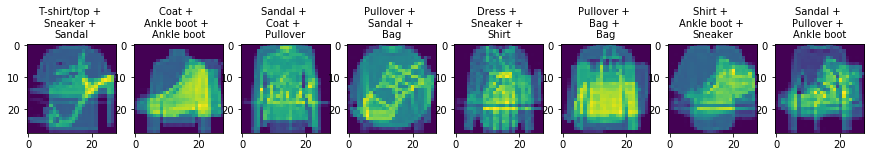

In [186]:
fig, axes = plt.subplots(1, 8, figsize=(15, 2))
for i in range(8):
    utils.show_np_arr(last_batch[i].cpu()[0, :, :], ax=axes[i])
    cls = [trainset.classes[last_ys[j][i]] for j in range(N_MIX)]
    axes[i].set_title(" + \n".join(cls), fontsize=10)
    pass

## N = 4

In [187]:
N_MIX = 4

In [188]:
LAMBDAS4 = [np.array([1, 1/x, 1/(x*x), 1/(x*x*x), 1/(x*x*x*x)])[:N_MIX] for x in np.linspace(1., N_MIX, 4)]
LAMBDAS4.append(np.array([1, *[0 for _ in LAMBDAS4[0][1:]]]))
LAMBDAS4 = [l / l.sum() for l in LAMBDAS4]
LAMBDAS4.reverse()
print(LAMBDAS4)

[array([1., 0., 0., 0.]), array([0.75294118, 0.18823529, 0.04705882, 0.01176471]), array([0.675, 0.225, 0.075, 0.025]), array([0.53333333, 0.26666667, 0.13333333, 0.06666667]), array([0.25, 0.25, 0.25, 0.25])]


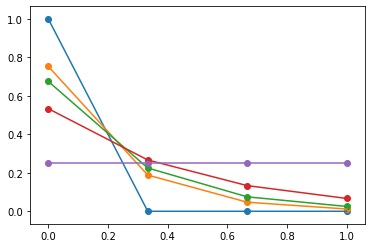

In [189]:
show_lambdas(LAMBDAS4)

In [197]:


USE_CUDA = True
RESULTS_FNAME = "r_fmn_cnn_n4"
N_EPOCHS = 100
N_BATCHES = None
LR = 0.001

print_ = utils.get_print(True, fname=RESULTS_FNAME)
model_getter = exp_models.CNN

test_accs, train_losses, val_losses, last_batch, last_ys = perform_experiment(LAMBDAS4)


Trying lambda= [1. 0. 0. 0.]
Performing n-mixup with N-mix: 4
Epoch[1/100]
val loss:2.3791 Epoch[1/100] Batch[0/600]
Batch shape: torch.Size([100, 1, 28, 28])
train loss:2.3791 Epoch[1/100] Batch[0/600]
train loss:0.4647 Epoch[1/100] Batch[50/600]
train loss:0.5897 Epoch[1/100] Batch[100/600]
train loss:0.4742 Epoch[1/100] Batch[150/600]
train loss:0.4242 Epoch[1/100] Batch[200/600]
train loss:0.2946 Epoch[1/100] Batch[250/600]
train loss:0.2702 Epoch[1/100] Batch[300/600]
train loss:0.3616 Epoch[1/100] Batch[350/600]
train loss:0.3459 Epoch[1/100] Batch[400/600]
train loss:0.2787 Epoch[1/100] Batch[450/600]
train loss:0.4501 Epoch[1/100] Batch[500/600]
train loss:0.2825 Epoch[1/100] Batch[550/600]
Epoch[1/100]
val loss:0.2422 Epoch[1/100] Batch[0/600]
Epoch[2/100]
train loss:0.2425 Epoch[2/100] Batch[0/600]
train loss:0.2337 Epoch[2/100] Batch[50/600]
train loss:0.1482 Epoch[2/100] Batch[100/600]
train loss:0.1719 Epoch[2/100] Batch[150/600]
train loss:0.2277 Epoch[2/100] Batch[200/60

train loss:0.0924 Epoch[14/100] Batch[0/600]
train loss:0.0912 Epoch[14/100] Batch[50/600]
train loss:0.1948 Epoch[14/100] Batch[100/600]
train loss:0.0758 Epoch[14/100] Batch[150/600]
train loss:0.1618 Epoch[14/100] Batch[200/600]
train loss:0.1034 Epoch[14/100] Batch[250/600]
train loss:0.1296 Epoch[14/100] Batch[300/600]
train loss:0.0486 Epoch[14/100] Batch[350/600]
train loss:0.0594 Epoch[14/100] Batch[400/600]
train loss:0.0545 Epoch[14/100] Batch[450/600]
train loss:0.0903 Epoch[14/100] Batch[500/600]
train loss:0.2401 Epoch[14/100] Batch[550/600]
Epoch[14/100]
val loss:0.0924 Epoch[14/100] Batch[0/600]
Epoch[15/100]
train loss:0.0557 Epoch[15/100] Batch[0/600]
train loss:0.1461 Epoch[15/100] Batch[50/600]
train loss:0.1480 Epoch[15/100] Batch[100/600]
train loss:0.1007 Epoch[15/100] Batch[150/600]
train loss:0.0506 Epoch[15/100] Batch[200/600]
train loss:0.1179 Epoch[15/100] Batch[250/600]
train loss:0.1118 Epoch[15/100] Batch[300/600]
train loss:0.0637 Epoch[15/100] Batch[350/

train loss:0.0737 Epoch[27/100] Batch[0/600]
train loss:0.1010 Epoch[27/100] Batch[50/600]
train loss:0.0373 Epoch[27/100] Batch[100/600]
train loss:0.0395 Epoch[27/100] Batch[150/600]
train loss:0.0903 Epoch[27/100] Batch[200/600]
train loss:0.0220 Epoch[27/100] Batch[250/600]
train loss:0.1086 Epoch[27/100] Batch[300/600]
train loss:0.1196 Epoch[27/100] Batch[350/600]
train loss:0.0562 Epoch[27/100] Batch[400/600]
train loss:0.0175 Epoch[27/100] Batch[450/600]
train loss:0.1284 Epoch[27/100] Batch[500/600]
train loss:0.0271 Epoch[27/100] Batch[550/600]
Epoch[27/100]
val loss:0.0273 Epoch[27/100] Batch[0/600]
Epoch[28/100]
train loss:0.0647 Epoch[28/100] Batch[0/600]
train loss:0.0346 Epoch[28/100] Batch[50/600]
train loss:0.0631 Epoch[28/100] Batch[100/600]
train loss:0.0461 Epoch[28/100] Batch[150/600]
train loss:0.0532 Epoch[28/100] Batch[200/600]
train loss:0.0459 Epoch[28/100] Batch[250/600]
train loss:0.0650 Epoch[28/100] Batch[300/600]
train loss:0.0930 Epoch[28/100] Batch[350/

train loss:0.0231 Epoch[40/100] Batch[0/600]
train loss:0.0290 Epoch[40/100] Batch[50/600]
train loss:0.0247 Epoch[40/100] Batch[100/600]
train loss:0.0301 Epoch[40/100] Batch[150/600]
train loss:0.0688 Epoch[40/100] Batch[200/600]
train loss:0.0160 Epoch[40/100] Batch[250/600]
train loss:0.0659 Epoch[40/100] Batch[300/600]
train loss:0.0832 Epoch[40/100] Batch[350/600]
train loss:0.0918 Epoch[40/100] Batch[400/600]
train loss:0.0442 Epoch[40/100] Batch[450/600]
train loss:0.0479 Epoch[40/100] Batch[500/600]
train loss:0.0341 Epoch[40/100] Batch[550/600]
Epoch[40/100]
val loss:0.0301 Epoch[40/100] Batch[0/600]
Epoch[41/100]
train loss:0.0169 Epoch[41/100] Batch[0/600]
train loss:0.0107 Epoch[41/100] Batch[50/600]
train loss:0.0367 Epoch[41/100] Batch[100/600]
train loss:0.0091 Epoch[41/100] Batch[150/600]
train loss:0.0852 Epoch[41/100] Batch[200/600]
train loss:0.0427 Epoch[41/100] Batch[250/600]
train loss:0.0381 Epoch[41/100] Batch[300/600]
train loss:0.0435 Epoch[41/100] Batch[350/

train loss:0.0252 Epoch[53/100] Batch[0/600]
train loss:0.0092 Epoch[53/100] Batch[50/600]
train loss:0.0054 Epoch[53/100] Batch[100/600]
train loss:0.0071 Epoch[53/100] Batch[150/600]
train loss:0.0496 Epoch[53/100] Batch[200/600]
train loss:0.0083 Epoch[53/100] Batch[250/600]
train loss:0.0544 Epoch[53/100] Batch[300/600]
train loss:0.0579 Epoch[53/100] Batch[350/600]
train loss:0.0330 Epoch[53/100] Batch[400/600]
train loss:0.0262 Epoch[53/100] Batch[450/600]
train loss:0.0155 Epoch[53/100] Batch[500/600]
train loss:0.0336 Epoch[53/100] Batch[550/600]
Epoch[53/100]
val loss:0.0227 Epoch[53/100] Batch[0/600]
Epoch[54/100]
train loss:0.0308 Epoch[54/100] Batch[0/600]
train loss:0.0171 Epoch[54/100] Batch[50/600]
train loss:0.0037 Epoch[54/100] Batch[100/600]
train loss:0.0104 Epoch[54/100] Batch[150/600]
train loss:0.0154 Epoch[54/100] Batch[200/600]
train loss:0.0075 Epoch[54/100] Batch[250/600]
train loss:0.0149 Epoch[54/100] Batch[300/600]
train loss:0.0672 Epoch[54/100] Batch[350/

...

train loss:1.5351 Epoch[42/100] Batch[250/600]
train loss:1.5922 Epoch[42/100] Batch[300/600]
train loss:1.5925 Epoch[42/100] Batch[350/600]
train loss:1.5848 Epoch[42/100] Batch[400/600]
train loss:1.5455 Epoch[42/100] Batch[450/600]
train loss:1.5642 Epoch[42/100] Batch[500/600]
train loss:1.5646 Epoch[42/100] Batch[550/600]
Epoch[42/100]
val loss:1.5551 Epoch[42/100] Batch[0/600]
Epoch[43/100]
train loss:1.6214 Epoch[43/100] Batch[0/600]
train loss:1.6286 Epoch[43/100] Batch[50/600]
train loss:1.5452 Epoch[43/100] Batch[100/600]
train loss:1.5110 Epoch[43/100] Batch[150/600]
train loss:1.5128 Epoch[43/100] Batch[200/600]
train loss:1.5790 Epoch[43/100] Batch[250/600]
train loss:1.4608 Epoch[43/100] Batch[300/600]
train loss:1.4676 Epoch[43/100] Batch[350/600]
train loss:1.5567 Epoch[43/100] Batch[400/600]
train loss:1.5041 Epoch[43/100] Batch[450/600]
train loss:1.5411 Epoch[43/100] Batch[500/600]
train loss:1.4773 Epoch[43/100] Batch[550/600]
Epoch[43/100]
val loss:1.6165 Epoch[43/

train loss:1.5717 Epoch[55/100] Batch[250/600]
train loss:1.4896 Epoch[55/100] Batch[300/600]
train loss:1.5956 Epoch[55/100] Batch[350/600]
train loss:1.4141 Epoch[55/100] Batch[400/600]
train loss:1.5681 Epoch[55/100] Batch[450/600]
train loss:1.5769 Epoch[55/100] Batch[500/600]
train loss:1.6277 Epoch[55/100] Batch[550/600]
Epoch[55/100]
val loss:1.4734 Epoch[55/100] Batch[0/600]
Epoch[56/100]
train loss:1.5232 Epoch[56/100] Batch[0/600]
train loss:1.5580 Epoch[56/100] Batch[50/600]
train loss:1.5167 Epoch[56/100] Batch[100/600]
train loss:1.5042 Epoch[56/100] Batch[150/600]
train loss:1.5164 Epoch[56/100] Batch[200/600]
train loss:1.6166 Epoch[56/100] Batch[250/600]
train loss:1.5693 Epoch[56/100] Batch[300/600]
train loss:1.5574 Epoch[56/100] Batch[350/600]
train loss:1.5337 Epoch[56/100] Batch[400/600]
train loss:1.5128 Epoch[56/100] Batch[450/600]
train loss:1.5246 Epoch[56/100] Batch[500/600]
train loss:1.4965 Epoch[56/100] Batch[550/600]
Epoch[56/100]
val loss:1.5089 Epoch[56/

train loss:1.5996 Epoch[68/100] Batch[250/600]
train loss:1.5219 Epoch[68/100] Batch[300/600]
train loss:1.5852 Epoch[68/100] Batch[350/600]
train loss:1.5517 Epoch[68/100] Batch[400/600]
train loss:1.4922 Epoch[68/100] Batch[450/600]
train loss:1.5548 Epoch[68/100] Batch[500/600]
train loss:1.5781 Epoch[68/100] Batch[550/600]
Epoch[68/100]
val loss:1.5643 Epoch[68/100] Batch[0/600]
Epoch[69/100]
train loss:1.4789 Epoch[69/100] Batch[0/600]
train loss:1.5686 Epoch[69/100] Batch[50/600]
train loss:1.5194 Epoch[69/100] Batch[100/600]
train loss:1.5318 Epoch[69/100] Batch[150/600]
train loss:1.5406 Epoch[69/100] Batch[200/600]
train loss:1.5561 Epoch[69/100] Batch[250/600]
train loss:1.5806 Epoch[69/100] Batch[300/600]
train loss:1.5488 Epoch[69/100] Batch[350/600]
train loss:1.5797 Epoch[69/100] Batch[400/600]
train loss:1.5419 Epoch[69/100] Batch[450/600]
train loss:1.5343 Epoch[69/100] Batch[500/600]
train loss:1.5545 Epoch[69/100] Batch[550/600]
Epoch[69/100]
val loss:1.5422 Epoch[69/

train loss:1.5452 Epoch[81/100] Batch[250/600]
train loss:1.5230 Epoch[81/100] Batch[300/600]
train loss:1.5534 Epoch[81/100] Batch[350/600]
train loss:1.5059 Epoch[81/100] Batch[400/600]
train loss:1.5222 Epoch[81/100] Batch[450/600]
train loss:1.5442 Epoch[81/100] Batch[500/600]
train loss:1.5473 Epoch[81/100] Batch[550/600]
Epoch[81/100]
val loss:1.5310 Epoch[81/100] Batch[0/600]
Epoch[82/100]
train loss:1.5441 Epoch[82/100] Batch[0/600]
train loss:1.4879 Epoch[82/100] Batch[50/600]
train loss:1.5456 Epoch[82/100] Batch[100/600]
train loss:1.5810 Epoch[82/100] Batch[150/600]
train loss:1.4789 Epoch[82/100] Batch[200/600]
train loss:1.5351 Epoch[82/100] Batch[250/600]
train loss:1.4975 Epoch[82/100] Batch[300/600]
train loss:1.5423 Epoch[82/100] Batch[350/600]
train loss:1.4997 Epoch[82/100] Batch[400/600]
train loss:1.5006 Epoch[82/100] Batch[450/600]
train loss:1.4883 Epoch[82/100] Batch[500/600]
train loss:1.5337 Epoch[82/100] Batch[550/600]
Epoch[82/100]
val loss:1.5488 Epoch[82/

train loss:1.4915 Epoch[94/100] Batch[250/600]
train loss:1.4974 Epoch[94/100] Batch[300/600]
train loss:1.5365 Epoch[94/100] Batch[350/600]
train loss:1.5308 Epoch[94/100] Batch[400/600]
train loss:1.5259 Epoch[94/100] Batch[450/600]
train loss:1.4845 Epoch[94/100] Batch[500/600]
train loss:1.5113 Epoch[94/100] Batch[550/600]
Epoch[94/100]
val loss:1.4906 Epoch[94/100] Batch[0/600]
Epoch[95/100]
train loss:1.5902 Epoch[95/100] Batch[0/600]
train loss:1.4946 Epoch[95/100] Batch[50/600]
train loss:1.5511 Epoch[95/100] Batch[100/600]
train loss:1.4521 Epoch[95/100] Batch[150/600]
train loss:1.5026 Epoch[95/100] Batch[200/600]
train loss:1.4943 Epoch[95/100] Batch[250/600]
train loss:1.5336 Epoch[95/100] Batch[300/600]
train loss:1.4951 Epoch[95/100] Batch[350/600]
train loss:1.5888 Epoch[95/100] Batch[400/600]
train loss:1.5786 Epoch[95/100] Batch[450/600]
train loss:1.4934 Epoch[95/100] Batch[500/600]
train loss:1.6494 Epoch[95/100] Batch[550/600]
Epoch[95/100]
val loss:1.5878 Epoch[95/

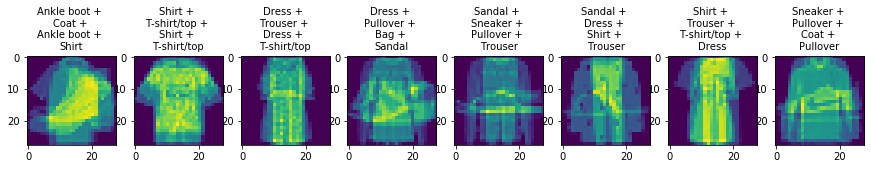

In [191]:
fig, axes = plt.subplots(1, 8, figsize=(15, 2))
for i in range(8):
    utils.show_np_arr(last_batch[i].cpu()[0, :, :], ax=axes[i])
    cls = [trainset.classes[last_ys[j][i]] for j in range(N_MIX)]
    axes[i].set_title(" + \n".join(cls), fontsize=10)
    pass